# Employee Attrition Prediction

## Notebook 5 - Final Model Evaluation & Business Recommendations

### Objective

The objective of this notebook is to evaluate the final selected machine learning model using comprehensive performance metrics and interpret the results from a business perspective.

In addition to assessing predictive performance, this notebook provides actionable HR recommendations, discusses project limitations, and identifies opportunities for future improvements.

In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [7]:
# =============================================================================
# Load Dataset
# =============================================================================

DATA_PATH = Path("../dataset/employee_attrition.csv")

df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [8]:
# =============================================================================
# Remove Constant and Identifier Columns
# =============================================================================

columns_to_drop = [
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]

df = df.drop(columns=columns_to_drop)

print(df.shape)

(1470, 31)


In [9]:
# =============================================================================
# Separate Features and Target
# =============================================================================

X = df.drop(columns="Attrition")

y = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

print(X.shape)
print(y.shape)

(1470, 30)
(1470,)


In [10]:
# =============================================================================
# Train-Test Split
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1176, 30)
Testing Shape: (294, 30)


In [11]:
# =============================================================================
# Numerical and Categorical Features
# =============================================================================

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include="object"
).columns.tolist()

print(f"Numerical Features: {len(numerical_features)}")
print(f"Categorical Features: {len(categorical_features)}")

Numerical Features: 23
Categorical Features: 7


In [12]:
# =============================================================================
# Numerical Pipeline
# =============================================================================

numerical_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# =============================================================================
# Categorical Pipeline
# =============================================================================

categorical_pipeline = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# =============================================================================
# Column Transformer
# =============================================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [13]:
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            SVC(
                C=10,
                kernel="linear",
                gamma="scale",
                class_weight="balanced",
                probability=True,
                random_state=42
            )
        )
    ]
)

final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Age','BusinessTravel','DailyRate',...,'YearsInCurrentRole', 'YearsSinceLastPromotion','YearsWithCurrManager']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of 

In [14]:
y_pred = final_model.predict(X_test)

y_prob = final_model.predict_proba(X_test)[:,1]

In [15]:
print(f"Accuracy : {accuracy_score(y_test,y_pred):.4f}")
print(f"Precision: {precision_score(y_test,y_pred):.4f}")
print(f"Recall   : {recall_score(y_test,y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test,y_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test,y_prob):.4f}")

Accuracy : 0.7687
Precision: 0.3735
Recall   : 0.6596
F1 Score : 0.4769
ROC AUC  : 0.7960


In [16]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.79      0.85       247
           1       0.37      0.66      0.48        47

    accuracy                           0.77       294
   macro avg       0.65      0.72      0.66       294
weighted avg       0.84      0.77      0.79       294



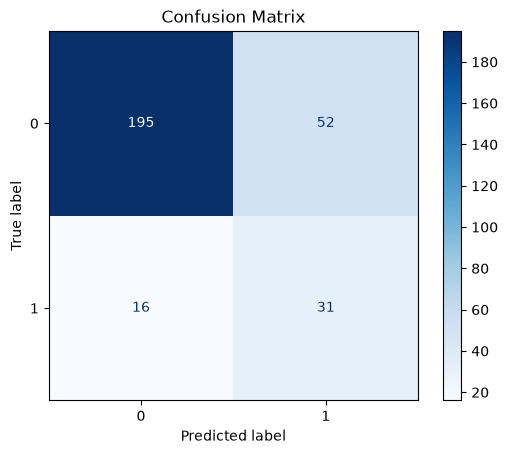

In [17]:
ConfusionMatrixDisplay.from_estimator(
    final_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

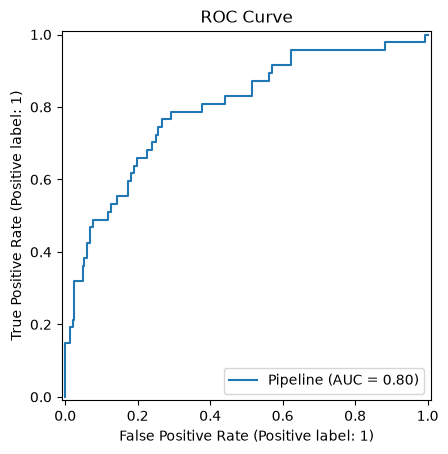

In [18]:
RocCurveDisplay.from_estimator(
    final_model,
    X_test,
    y_test
)

plt.title("ROC Curve")
plt.show()

## Business Interpretation

The selected Support Vector Machine model achieved the highest overall F1-score after evaluating multiple imbalance handling strategies.

The model successfully identifies a significant proportion of employees at risk of attrition while maintaining a reasonable balance between precision and recall.

Although the model produces some false positives, this is generally acceptable in employee attrition prediction because retaining a valuable employee is often less costly than replacing one who unexpectedly leaves the organization.

The model can therefore serve as an effective decision-support tool for HR departments by highlighting employees who may benefit from proactive retention initiatives.

## Conclusion

This project successfully developed an end-to-end employee attrition prediction system using supervised machine learning techniques.

Several classification algorithms were evaluated, followed by hyperparameter tuning and class imbalance experiments. Among all evaluated approaches, the Support Vector Machine with class weighting achieved the best balance between precision and recall, making it the final selected model.

The project demonstrates the complete machine learning lifecycle, including data exploration, preprocessing, feature engineering, model development, evaluation, and business interpretation.

The resulting solution can support HR professionals in identifying employees at higher risk of attrition, enabling proactive retention strategies and more informed workforce planning.